In [4]:
""" A Decision Tree Regressor is a model that predicts continuous values (numbers) by splitting data into smaller groups based on feature conditions.
"""
# Rituals
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score
from sklearn import tree
from sklearn.tree import plot_tree

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


(20640, 9)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits
[CV] END criterion=squared_error, max_depth=4, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, splitter=best; total time=   0.0s
[CV] END criterion=squared_error, max_depth=4, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, splitter=best; total time=   0.0s
[CV] END criterion=squared_error, max_depth=4, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, splitter=best; total time=   0.0s
[CV] END criterion=squared_error, max_depth=4, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, splitter=best; total time=   0.0s
[CV] END criterion=squared_error, max_depth=4, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, splitter=best; total time=   0.0s
[CV] END criterion=squared_error, max_depth=4, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, splitter=random; total time=   0.0s
[CV] END criterion=squared_error, max_depth=4, max_features=sqrt, min_samples_leaf=1, mi

' acc under regressor 0.5843'

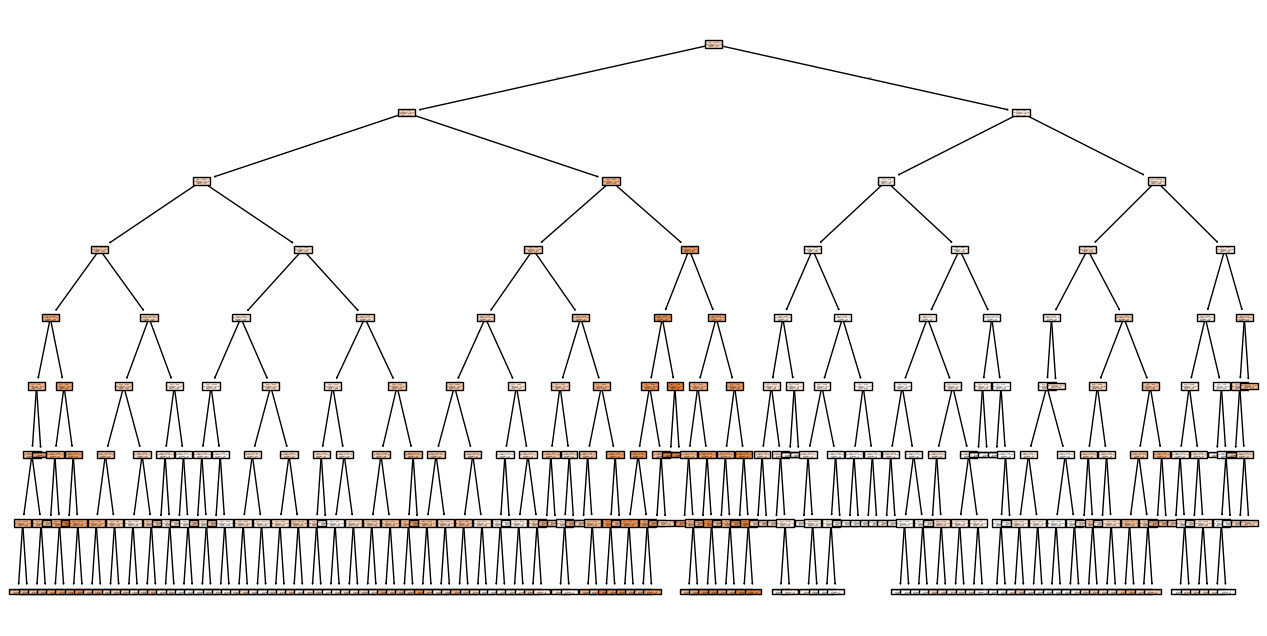

In [6]:
data=fetch_california_housing()
df=pd.DataFrame(data.data,columns= data.feature_names)
display(df.head(5))
df["Target"]=data.target
df_sample=df.sample(n=5000,random_state=42) # cutting off the large data set cause it takes lot of time. 
x=df_sample.iloc[:,:-1]
y=df_sample["Target"]
# display(y.head(4))
# display(x.head(4))
display(df.shape)
#------------------------ train test split ---------------------
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)
regr=DecisionTreeRegressor()
parameter={
    'criterion':['squared_error','absolute_error','friedman_mse'],
    'splitter':['best','random'],
    'max_depth':[4,6,8,10],
    'max_features':['sqrt','log2'],
    'min_samples_split':[2,5,8],
    'min_samples_leaf':[1,3,5]
}
model=GridSearchCV(regr,param_grid=parameter,cv=5,scoring='r2',verbose=2)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
acc=r2_score(y_test,y_pred)
display(f" acc under regressor {round(acc,4)}")

# ----------------------- Plot the tree -----------------------
plt.figure(figsize=(16,8))
plot_tree(model.best_estimator_,filled=True)
plt.show()